# Do you see very large icons when opening Paraview?

Try following the indications provided here (for Windows):

https://discourse.paraview.org/t/i-am-using-paraview-on-windows-10-and-the-application-resolution-is-low-with-big-icons/6370

In [1]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [14]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

In [15]:
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)

my_io_path = current_path + "/cfd-labs/Lab08-SNES-and-postprocessing/" 
# my_io_path = current_path+"/"
print(my_io_path)

/home/aless
/home/aless/cfd-labs/Lab08-SNES-and-postprocessing/


---
---
# Exercise 1

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - {\rm div}(2\nu\varepsilon(\boldsymbol{u})) + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = 4y(1-y)\boldsymbol{i} & {\rm on} \ \Gamma_{\rm in}, \\
(2\nu\nabla\varepsilon(\boldsymbol{u}) - pI)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm out}, \\
%\left[\begin{aligned}
%\text{(i) }&\boldsymbol{u} = \boldsymbol{0}\\
%\text{(ii) }&\boldsymbol{u}\cdot\boldsymbol{n} = 0, %\quad (2\nu\nabla\varepsilon(\boldsymbol{u})-pI)%\boldsymbol{n} \cdot \boldsymbol{t} = 0
%\end{aligned}\right]
\boldsymbol{u} = \boldsymbol{0}
& {\rm on} \ \Gamma_{\rm wall}=\partial\Omega\setminus(\Gamma_{\rm in}\cup\Gamma_{\rm out}). \\
\end{cases}
\end{equation*}

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (31,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (32,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (33,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (41,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (42,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (43,) is empty. This is likely an error. Did you choose the right label?


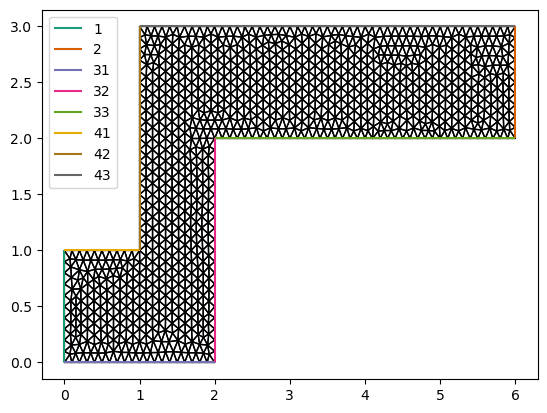

In [16]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(my_io_path+'elbow3bis.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

### Variational form - residual

In [17]:
# inputs:   uh, ph  components of an actual Function (NOT trial functions)
#           v, q    components of a TestFunction
#           nu, f   viscosity and source function
# output:   G       linear form (i.e. functional) representing the evaluation of
#                   the residual for a given solution (uh,ph), for any test function
def nonlinear_problem_residual(uh, v, ph, q, nu, f):
    G = inner(dot(grad(uh), uh), v) * dx  \
        + 2*nu * inner(sym(grad(uh)), sym(grad(v))) * dx  \
        - div(v) * ph * dx  \
        + q * div(uh) * dx \
        - inner(f, v) * dx
    return G

### FE spaces, data, BCs

In [21]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Data and boundary conditions
nu = 0.02
f = Constant((0.,0.))
x = SpatialCoordinate(mesh)

u_in = (4*x[1]*(1-x[1]), 0.)
bc_in = DirichletBC(W.sub(0), u_in, 1)

# # On the mesh elbow3.msh
# bc_wall = DirichletBC(W.sub(0), Constant((0.,0.)), (3,4))

# On the mesh elbow3bis.msh
bc_noslip = DirichletBC(W.sub(0), Constant((0.,0.)), (31,32,33,41,42,43))

bc_freeslip_x = DirichletBC(W.sub(0).sub(0), Constant(0.), (32,42))
bc_freeslip_y = DirichletBC(W.sub(0).sub(1), Constant(0.), (31,33,41,43))

# Uncomment to choose between no-slip and free-slip conditions.
# bcs = (bc_in, bc_noslip)
bcs = (bc_in, bc_freeslip_x, bc_freeslip_y)

### Assembly of the residual

In [22]:
# NO TRIAL FUNCTIONS!
v, q = TestFunctions(W)

wh = Function(W)
# uh, ph = wh.subfunctions  # NO: this is fine for BCs and post-processing, but NOT to define the residual
uh, ph = split(wh)
# NB:   wh (and also uh,ph) must be created before creating G.
#       If you re-define wh (or uh,ph), you MUST re-compute G,
#       since G is the evaluation of the residual on a specific wh.

# Notice that G needs to be a functional, not a bilinear form
G = nonlinear_problem_residual(uh, v, ph, q, nu, f)
print("rank of the residual form:\t", len(G.arguments()))   # 1: only test function

u, p = TrialFunctions(W)
print("rank of a bilinear form:\t", len((inner(u,v)*dx).arguments())) # 2: trial and test functions

rank of the residual form:	 1
rank of a bilinear form:	 2


### Actual solution

In [23]:
param=( {'snes_type':'newtonls', # nonlinear solver types: https://petsc.org/release/manual/snes/#the-nonlinear-solvers
       'snes_monitor':'',        # activate logging options
       'snes_monitoring_lg_residualnorm':'', # print ||G|| at each iteration
       'snes_rtol':1e-6, 'snes_atol':1e-10, 'snes_stol':1e-14, 'snes_maxit':1000,
       'ksp_rtol':1e-8
       })
solve(G == 0, wh, bcs=bcs, solver_parameters=param)

# Equivalent:
#     nlvpb = NonlinearVariationalProblem(G, wh, bcs=bcs)
#     param = ...
#     solver = NonlinearVariationalSolver(nlvpb, solver_parameters=param)
#     solver.solve()

  0 SNES Function norm 2.999908281035e-01
  1 SNES Function norm 8.639626283065e-02
  2 SNES Function norm 3.710459048974e-02
  3 SNES Function norm 1.315059597114e-02
  4 SNES Function norm 6.987260833123e-04
  5 SNES Function norm 2.873331013481e-06
  6 SNES Function norm 7.209399438736e-12


### Stream function problem

In [24]:
Z = FunctionSpace(mesh, 'P', 1)
psi = TrialFunction(Z)
eta = TestFunction(Z)

a_stream = inner(grad(psi), grad(eta)) * dx
omega = rot(uh)                               # by pre-defined UFL command
# omega = Dx(uh_out.sub(1),0) - Dx(uh_out.sub(0),1)   # by components (UFL syntax) - using uh_out: see next cell
L_stream = inner( omega , eta) * dx

# # On the mesh elbow3.msh
# bc_stream_1 = DirichletBC(Z, Constant(2.0/3.0), 3)
# bc_stream_2 = DirichletBC(Z, Constant(0.0), 4)

# On the mesh elbow3bis.msh
bc_stream_1 = DirichletBC(Z, Constant(0.0), (31,32,33))
bc_stream_2 = DirichletBC(Z, Constant(2.0/3.0), (41,42,43))

bcs_stream = (bc_stream_1, bc_stream_2)

psi_h = Function(Z)
solve(a_stream == L_stream, psi_h, bcs_stream)

### Post-processing

Text(0.5, 1.0, 'velocity')

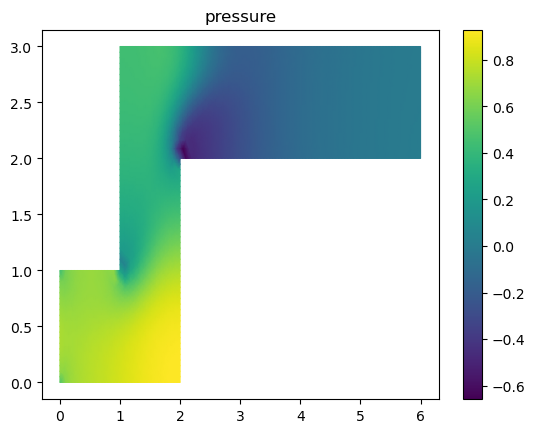

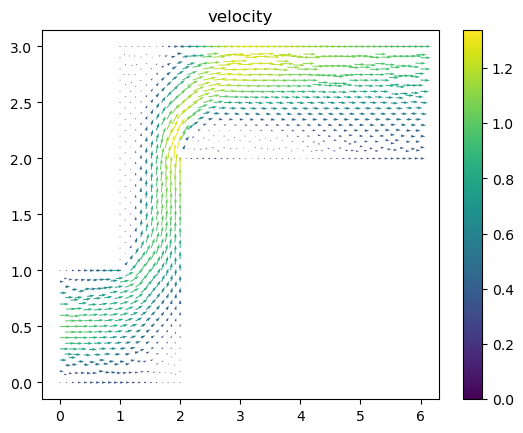

In [26]:
# WARNING
# uh,ph were created as split(wh), by which uh,ph are proxies to access wh:
# this is NECESSARY for the residual G to have the suitable type for Firedrake's nonlinear solver.
# For post-processing, instead, we need a more "direct" access to the FE functions
# corresponding to the velocity and pressure component of the solution:
# this is achieved by wh.subfunctions
uh_out, ph_out = wh.subfunctions

fig, ax = plt.subplots()
col = tripcolor(ph_out, axes=ax)
plt.colorbar(col)
plt.title('pressure')

fig, ax = plt.subplots()
col = quiver(uh_out, axes=ax)
plt.colorbar(col)
plt.title('velocity')

# col = tricontour(psi_h)   # the levels (i.e. values) of the contour lines chosen by default -> in the next lines we choose these levels
# levels = np.linspace(0, 2.0/3.0, 10)  # psi_h is not exactly =0 on the top wall -> the 0 streamline seems to be interrupted
levels = np.linspace(1e-15, 2.0/3.0-1e-15, 10)
col = tricontour(psi_h, levels) # psi_h is already a Function: do not need to extract components
plt.colorbar(col)

# vtk output for Paraview
basename = 'lab08_elbow3_freeslip_' # give different names to have more cases in the same folder
outfileU = File(my_io_path+"Lab08/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"Lab08/"+basename+"pressure.pvd")
outfilePsi = File(my_io_path+"Lab08/"+basename+"stream.pvd")
uh_out.rename("Velocity")   # this names will be used in Paraview
ph_out.rename("Pressure")
psi_h.rename("psi")
outfileU.write(uh_out)
outfileP.write(ph_out)
outfilePsi.write(psi_h)

In [28]:
normal = FacetNormal(mesh)
drag = assemble(-2*nu*inner(dot(sym(grad(uh_out)), normal), Constant((1.,0.))) * ds(33))
# since here normal=(0,-1), the following is equivalent
# drag = assemble(-nu*(-Dx(uh_out.sub(0), 1)-Dx(uh_out.sub(1), 0)) * ds(33)))
print('Drag force on lower, downstream wall =', drag)

flowrate = assemble(inner(uh_out, normal) * ds(2))
print('Outlet flowrate =', flowrate, '(exact should be',2.0/3.0,')')

impervious_walls = assemble(abs(inner(uh_out, normal)) * ds((31,32,33,41,42,43)))
print('Flow through walls =', impervious_walls)

delta_p = (
    assemble(ph_out * ds(1)) / 1.0  # average inlet pressure
    -
    assemble(ph_out * ds(2)) / 1.0  # average outlet pressure
)
print('Total pressure jump =', delta_p)

Drag force on lower, downstream wall = 0.0017926294569428145
Outlet flowrate = 0.6666666666666928 (exact should be 0.6666666666666666 )
Flow through walls = 2.487060768319613e-16
Total pressure jump = 0.6651180349450186


---
---
# Exercise 2 - homework

\begin{equation*}
\begin{cases}
\frac{\partial\boldsymbol{u}}{\partial t} + (\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \frac{2}{\rm Re}{\rm div}\,\varepsilon(\boldsymbol{u}) + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, t\in(0,T), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, t\in(0,T), \\
\boldsymbol{u} = 1\boldsymbol{i} & {\rm on} \ \Gamma_{\rm in}, t\in(0,T), \\
\left(\frac{2}{\rm Re}\varepsilon(\boldsymbol{u}) - pI\right)\boldsymbol{n} = \boldsymbol{0} & {\rm on} \ \Gamma_{\rm out}, t\in(0,T), \\
\boldsymbol{u}\cdot\boldsymbol{n} = 0, \quad \left(\frac{2}{\rm Re}\varepsilon(\boldsymbol{u})-pI\right)\boldsymbol{n} \cdot \boldsymbol{t} = 0
& {\rm on} \ \Gamma_{\rm wall}, t\in(0,T),\\
\boldsymbol{u}=\boldsymbol{0} & {\rm on} \ \Gamma_{\rm cyl}, t\in(0,T),\\
\boldsymbol{u}=\boldsymbol{0} & {\rm in} \ \Omega, t=0.
\end{cases}
\end{equation*}

In [ ]:
# Import mesh: set the path correctly!
# See cell before Exercise 1 about current path.
mesh = Mesh(my_io_path+'meshes/cylinder-ns.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper right')

### FE spaces, data, BCs

In [ ]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Data and boundary conditions
Re = 10
f = Constant((0.,0.))
x = SpatialCoordinate(mesh)

bc_in = DirichletBC(W.sub(0), Constant((1., 0.)), 1)
bc_walls = DirichletBC(W.sub(0).sub(1), Constant(0.), (3, 4))
bc_cyl = DirichletBC(W.sub(0), Constant((0.,0.)), (3,4,5))

bcs = (bc_in, bc_cyl)

### Variational problem - residual

In [ ]:
# inputs:   uh, ph  components of an actual Function (NOT trial functions)
#           v, q    components of a TestFunction
#           nu, f   viscosity and source function
# output:   G       linear form (i.e. functional) representing the evaluation of
#                   the residual for a given solution (uh,ph), for any test function
def nonlinear_problem_residual(uh, v, ph, q, nu, f):
    G = inner(dot(grad(uh), uh), v) * dx  \
        + 2.0/Re * inner(sym(grad(uh)), sym(grad(v))) * dx  \
        - div(v) * ph * dx  \
        + q * div(uh) * dx \
        - inner(f, v) * dx
    return G

### Initial condition and settings

In [ ]:
uh_old = Function(V)
uh_old.interpolate(Constant((0., 0.)))

wh = Function(W)
uh, ph = split(wh)
# NB:   wh (and also uh,ph) must be created and properly set before assembling G.
#       If wh (or uh,ph) changes, you MUST re-assemble G,
#       since G is the evaluation of the residual on a specific wh.
uh_out, ph_out = wh.subfunctions
uh_out.assign(uh_old)       # must be done through a subfunction, not through a split component
v, q = TestFunctions(W)

t0 = 0
T = 10.
dt = 0.2
export_stride = 5     # export solution every other export_stride timesteps
time_index = 0

param = ( {'snes_type':'newtonls', # nonlinear solver types: https://petsc.org/release/manual/snes/#the-nonlinear-solvers
       'snes_monitor':'',        # activate logging options
       'snes_monitoring_lg_residualnorm':'', # print ||G|| at each iteration
       'snes_rtol':1e-6, 'snes_atol':1e-10, 'snes_stol':1e-14, 'snes_maxit':10
       }
)

basename = 'lab08_cylinder_'
outfileU = File(my_io_path+"cyl-ns/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"cyl-ns/"+basename+"pressure.pvd")
uh_out.rename('Velocity')
ph_out.rename('Pressure')
outfileU.write(uh_out, time=0)
outfileP.write(ph_out, time=0)

In [ ]:
for t in np.arange(t0, T+0.1*dt, dt):
    print('\ntime t = ', t)
    time_index += 1

    G = 1.0/dt*inner(uh,v)*dx - 1.0/dt*inner(uh_old,v)*dx + nonlinear_problem_residual(uh, v, ph, q, nu, f)
    solve(G == 0, wh, bcs=bcs, solver_parameters=param)

    if time_index % export_stride == 0:
        uh_out.rename('Velocity')
        ph_out.rename('Pressure')
        outfileU.write(uh_out, time=t)
        outfileP.write(ph_out, time=t)

        fig, ax = plt.subplots()
        col = tripcolor(ph_out, axes=ax)
        plt.colorbar(col)
        plt.title('pressure')

        fig, ax = plt.subplots()
        col = quiver(uh_out, axes=ax)
        plt.colorbar(col)
        plt.title('velocity')

    uh_old.assign(uh_out)